# Анализ продаж интернет-магазина

## Цель проекта

Проанализировать продажи интернет-магазина с помощью SQL и Python, определить основные источники выручки, поведение клиентов и динамику продаж.

## Основные задачи:

- рассчитать общую выручку;
- определить наиболее прибыльные товары;
- проанализировать динамику выручки;
- изучить продажи по категориям и городам;
- оценить повторные покупки клиентов;
- провести ABC-анализ товаров;
- определить средний чек и среднее количество товаров в заказе.

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2

In [83]:
import os
from dotenv import load_dotenv
import psycopg2

load_dotenv()

connection = psycopg2.connect(
    host=os.getenv("DB_HOST"),
    database=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    port=os.getenv("DB_PORT")
)

print("Подключение успешно")

Подключение успешно


In [44]:
query = """
SELECT *
FROM orders;
"""

df_orders = pd.read_sql(query, connection)

df_orders.head()

C:\Users\Вадим\AppData\Local\Temp\ipykernel_18240\738254302.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_orders = pd.read_sql(query, connection)


,order_id,customer_id,order_date,status
0,1,1,2024-01-20,completed
1,2,2,2024-01-25,completed
2,3,3,2024-02-10,completed
3,4,4,2024-02-15,cancelled
4,5,5,2024-03-01,completed


1. Загрузка таблиц из PostgreSQL.

Загружаем основные таблицы интернет-магазина для дальнейшего анализа:

- orders — информация о заказах;
- customers — информация о клиентах;
- products — информация о товарах;
- order_items — состав заказов.

In [45]:
query_customers = """
SELECT *
FROM customers;
"""

df_customers = pd.read_sql(query_customers, connection)


query_products = """
SELECT *
FROM products;
"""

df_products = pd.read_sql(query_products, connection)


query_order_items = """
SELECT *
FROM order_items;
"""

df_order_items = pd.read_sql(query_order_items, connection)

C:\Users\Вадим\AppData\Local\Temp\ipykernel_18240\2215334736.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customers = pd.read_sql(query_customers, connection)
C:\Users\Вадим\AppData\Local\Temp\ipykernel_18240\2215334736.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_products = pd.read_sql(query_products, connection)
C:\Users\Вадим\AppData\Local\Temp\ipykernel_18240\2215334736.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_order_items = pd.read_sql(query_order_items, connection)


In [46]:
df_customers.head()

,customer_id,registration_date,city
0,1,2024-01-10,Москва
1,2,2024-01-15,Санкт-Петербург
2,3,2024-02-01,Казань
3,4,2024-02-10,Новосибирск
4,5,2024-03-05,Екатеринбург


In [47]:
df_orders.head()

,order_id,customer_id,order_date,status
0,1,1,2024-01-20,completed
1,2,2,2024-01-25,completed
2,3,3,2024-02-10,completed
3,4,4,2024-02-15,cancelled
4,5,5,2024-03-01,completed


In [48]:
df_products.head()

,product_id,product_name,category,price
0,1,iPhone 15,Electronics,90000.0
1,2,Samsung Galaxy S24,Electronics,80000.0
2,3,Ноутбук Lenovo,Electronics,70000.0
3,4,Наушники Sony,Electronics,15000.0
4,5,Клавиатура Logitech,Electronics,7000.0


In [49]:
df_order_items.head()

,order_id,product_id,quantity
0,1,1,1
1,1,4,2
2,2,3,1
3,2,5,1
4,3,2,1


2. Проверка структуры данных.

Проверяем количество строк в загруженных таблицах.

In [50]:
print("Orders:", df_orders.shape)
print("Customers:", df_customers.shape)
print("Products:", df_products.shape)
print("Order items:", df_order_items.shape)

Orders: (15, 4)
Customers: (10, 3)
Products: (10, 4)
Order items: (22, 3)


3. Анализ выручки.

Рассчитаем общую выручку магазина по завершённым заказам.

Выручка = Цена товара × количество проданных единиц

In [51]:
revenue_df = (
    df_orders
    .merge(df_order_items, on="order_id")
    .merge(df_products, on="product_id")
)

revenue_df.head()

,order_id,customer_id,order_date,status,product_id,quantity,product_name,category,price
0,1,1,2024-01-20,completed,1,1,iPhone 15,Electronics,90000.0
1,1,1,2024-01-20,completed,4,2,Наушники Sony,Electronics,15000.0
2,2,2,2024-01-25,completed,3,1,Ноутбук Lenovo,Electronics,70000.0
3,2,2,2024-01-25,completed,5,1,Клавиатура Logitech,Electronics,7000.0
4,3,3,2024-02-10,completed,2,1,Samsung Galaxy S24,Electronics,80000.0


In [52]:
revenue_df["revenue"] = (
    revenue_df["price"] *
    revenue_df["quantity"]
)

revenue_df.head()

,order_id,customer_id,order_date,status,product_id,quantity,product_name,category,price,revenue
0,1,1,2024-01-20,completed,1,1,iPhone 15,Electronics,90000.0,90000.0
1,1,1,2024-01-20,completed,4,2,Наушники Sony,Electronics,15000.0,30000.0
2,2,2,2024-01-25,completed,3,1,Ноутбук Lenovo,Electronics,70000.0,70000.0
3,2,2,2024-01-25,completed,5,1,Клавиатура Logitech,Electronics,7000.0,7000.0
4,3,3,2024-02-10,completed,2,1,Samsung Galaxy S24,Electronics,80000.0,80000.0


In [53]:
completed_revenue = revenue_df[
    revenue_df["status"] == "completed"
]
total_revenue = completed_revenue["revenue"].sum()
print(f"Общая выручка: {total_revenue:,.0f} ₽")

Общая выручка: 820,500 ₽


4. Динамика выручки по месяцам.

Рассчитаем выручку магазина по месяцам на основе завершённых заказов и построим график.

In [54]:
completed_revenue["order_date"] = pd.to_datetime(
    completed_revenue["order_date"]
)

In [55]:
completed_revenue["month"] = (
    completed_revenue["order_date"]
    .dt.to_period("M")
    .astype(str)
)

completed_revenue.head()

,order_id,customer_id,order_date,status,product_id,quantity,product_name,category,price,revenue,month
0,1,1,2024-01-20,completed,1,1,iPhone 15,Electronics,90000.0,90000.0,2024-01
1,1,1,2024-01-20,completed,4,2,Наушники Sony,Electronics,15000.0,30000.0,2024-01
2,2,2,2024-01-25,completed,3,1,Ноутбук Lenovo,Electronics,70000.0,70000.0,2024-01
3,2,2,2024-01-25,completed,5,1,Клавиатура Logitech,Electronics,7000.0,7000.0,2024-01
4,3,3,2024-02-10,completed,2,1,Samsung Galaxy S24,Electronics,80000.0,80000.0,2024-02


In [56]:
monthly_revenue = (
    completed_revenue
    .groupby("month")["revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,month,revenue
0,2024-01,197000.0
1,2024-02,83000.0
2,2024-03,137000.0
3,2024-04,70000.0
4,2024-05,89500.0
5,2024-06,120000.0
6,2024-07,110000.0
7,2024-08,14000.0


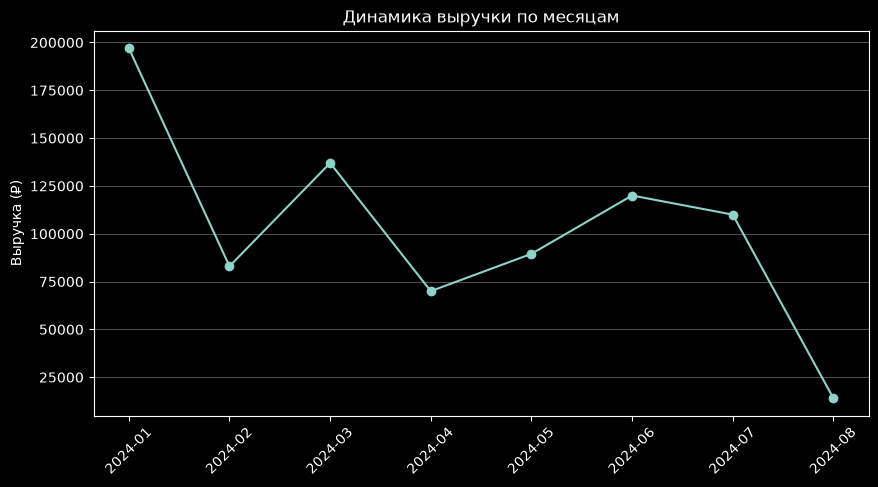

In [57]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.title("Динамика выручки по месяцам")
plt.ylabel("Выручка (₽)")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)

plt.show()


Вывод.

Максимальная выручка была зафиксирована в январе 2024 года и составила 197 000 ₽.

Минимальная выручка наблюдалась в августе 2024 года — 14 000 ₽.

После снижения в феврале выручка восстановилась в марте, затем вновь снизилась в апреле и постепенно росла до июня. Резкое падение в августе связано с небольшим количеством завершённых заказов в этом месяце.

5. Выручка по категориям товаров

Посчитаем, сколько выручки приносит каждая категория товаров.

In [58]:
category_revenue = (
    completed_revenue
    .groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue

,category,revenue
0,Electronics,643000.0
1,Furniture,110000.0
2,Home,60000.0
3,Books,7500.0


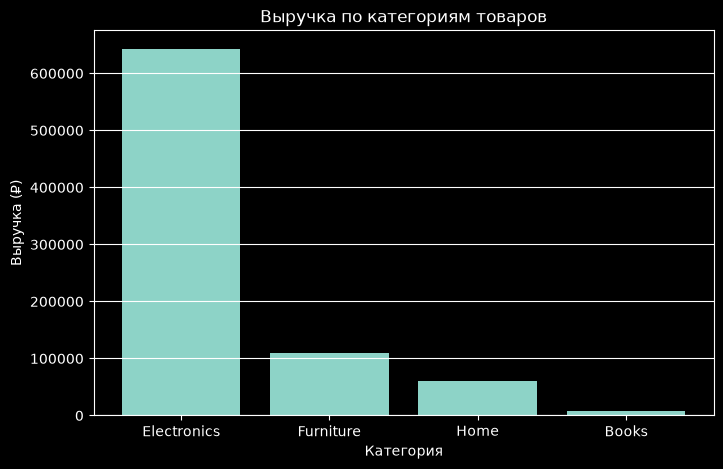

In [59]:
plt.figure(figsize=(8,5))

plt.bar(
    category_revenue["category"],
    category_revenue["revenue"]
)

plt.title("Выручка по категориям товаров")
plt.xlabel("Категория")
plt.ylabel("Выручка (₽)")

plt.grid(axis="y")

plt.show()

Вывод.

Наибольшую выручку принесла категория Electronics — 643 000 ₽, что составляет основную часть дохода магазина.

Категория Furniture заняла второе место с выручкой 110 000 ₽. Далее следуют Home (60 000 ₽) и Books (7 500 ₽).

Полученные результаты показывают, что спрос покупателей сосредоточен преимущественно на товарах категории Electronics. Остальные категории приносят значительно меньшую долю выручки, что может быть связано с более низким спросом или меньшей стоимостью товаров.

6. Топ клиентов по сумме покупок

In [60]:
top_customers = (
    completed_revenue
    .groupby("customer_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_customers

,customer_id,revenue
0,1,200000.0
1,7,160000.0
2,3,123000.0
3,6,97000.0
4,2,91000.0
5,10,85000.0
6,5,60000.0
7,9,4500.0


In [61]:
top_customers = top_customers.merge(
    df_customers,
    on="customer_id"
)

top_customers

,customer_id,revenue,registration_date,city
0,1,200000.0,2024-01-10,Москва
1,7,160000.0,2024-04-01,Самара
2,3,123000.0,2024-02-01,Казань
3,6,97000.0,2024-03-20,Москва
4,2,91000.0,2024-01-15,Санкт-Петербург
5,10,85000.0,2024-05-25,Сочи
6,5,60000.0,2024-03-05,Екатеринбург
7,9,4500.0,2024-05-10,Пермь


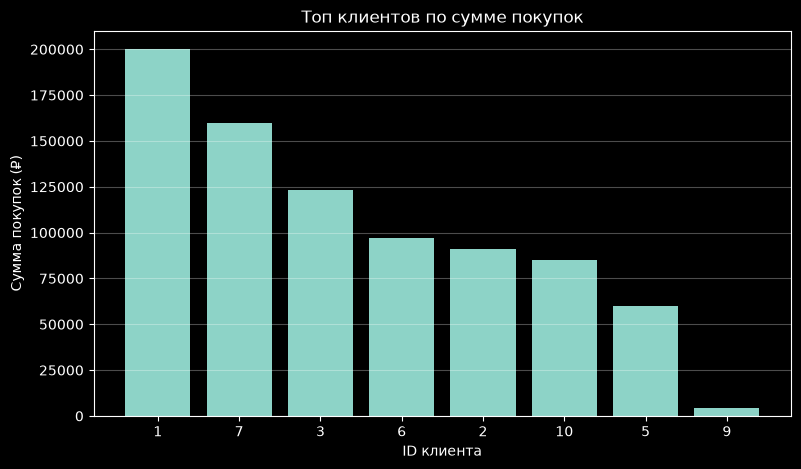

In [62]:
plt.figure(figsize=(9,5))

plt.bar(
    top_customers["customer_id"].astype(str),
    top_customers["revenue"]
)

plt.title("Топ клиентов по сумме покупок")
plt.xlabel("ID клиента")
plt.ylabel("Сумма покупок (₽)")

plt.grid(axis="y", alpha=0.3)

plt.show()

Вывод.

Наибольшую выручку магазину принёс клиент №1 из Москвы, совершив покупки на сумму **200 000 ₽**.

Второе место занял клиент №7 из Самары с суммой покупок **160 000 ₽**, а третье — клиент №3 из Казани (**123 000 ₽**).

Можно заметить, что два клиента из Москвы входят в число лидеров по сумме покупок. При этом основная часть выручки формируется небольшим количеством наиболее активных покупателей.

7. ABC-анализ товаров

Определим товары, которые формируют основную часть выручки магазина.

In [63]:
product_revenue = (
    completed_revenue
    .groupby("product_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

product_revenue

,product_name,revenue
0,iPhone 15,270000.0
1,Samsung Galaxy S24,160000.0
2,Ноутбук Lenovo,140000.0
3,Стол компьютерный,80000.0
4,Кофеварка Bosch,60000.0
5,Наушники Sony,45000.0
6,Кресло офисное,30000.0
7,Клавиатура Logitech,28000.0
8,Книга по Python,7500.0


In [64]:
product_revenue["share"] = (
    product_revenue["revenue"]
    / product_revenue["revenue"].sum()
    * 100
)

In [65]:
product_revenue["cumulative_share"] = (
    product_revenue["share"].cumsum()
)

In [66]:
product_revenue["ABC"] = "C"

product_revenue.loc[
    product_revenue["cumulative_share"] <= 80,
    "ABC"
] = "A"

product_revenue.loc[
    (product_revenue["cumulative_share"] > 80)
    &
    (product_revenue["cumulative_share"] <= 95),
    "ABC"
] = "B"

8. ABC-анализ товаров

ABC-анализ позволяет определить товары, которые формируют основную часть выручки магазина.

Категории:
- **A** — товары, которые дают примерно первые 80% выручки;
- **B** — товары со средней значимостью;
- **C** — товары с минимальным вкладом в общую выручку.

In [67]:
product_revenue

,product_name,revenue,share,cumulative_share,ABC
0,iPhone 15,270000.0,32.906764,32.906764,A
1,Samsung Galaxy S24,160000.0,19.500305,52.407069,A
2,Ноутбук Lenovo,140000.0,17.062767,69.469835,A
3,Стол компьютерный,80000.0,9.750152,79.219988,A
4,Кофеварка Bosch,60000.0,7.312614,86.532602,B
5,Наушники Sony,45000.0,5.484461,92.017063,B
6,Кресло офисное,30000.0,3.656307,95.673370,C
7,Клавиатура Logitech,28000.0,3.412553,99.085923,C
8,Книга по Python,7500.0,0.914077,100.000000,C


Вывод

По результатам ABC-анализа к категории **A** относятся 4 товара:

- iPhone 15
- Samsung Galaxy S24
- Ноутбук Lenovo
- Стол компьютерный

Эти товары формируют около **79% общей выручки магазина** и являются ключевыми для бизнеса.

Категория **B** включает товары со средним вкладом в продажи:

- Кофеварка Bosch
- Наушники Sony

Категория **C** содержит товары с минимальным влиянием на выручку:

- Кресло офисное
- Клавиатура Logitech
- Книга по Python

Основной фокус при управлении ассортиментом стоит уделять товарам категории **A**, так как они обеспечивают основную часть дохода магазина.

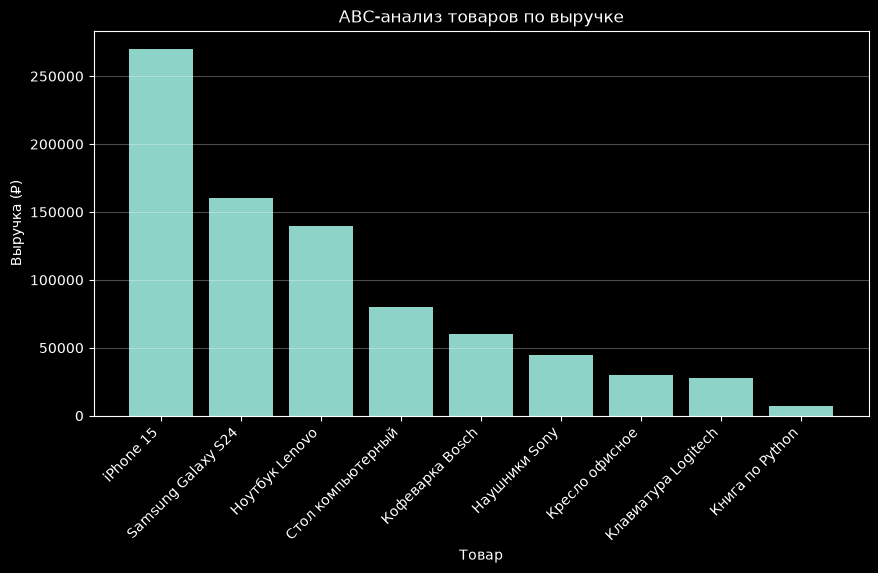

In [68]:
plt.figure(figsize=(10,5))

plt.bar(
    product_revenue["product_name"],
    product_revenue["revenue"]
)

plt.xticks(rotation=45, ha="right")

plt.title("ABC-анализ товаров по выручке")
plt.xlabel("Товар")
plt.ylabel("Выручка (₽)")

plt.grid(axis="y", alpha=0.3)

plt.show()

9. Повторные покупки клиентов.

Проанализируем количество заказов на одного клиента и определим долю клиентов, совершивших повторные покупки.

In [69]:
customer_orders = (
    df_orders[df_orders["status"] == "completed"]
    .groupby("customer_id")["order_id"]
    .count()
    .reset_index(name="orders_count")
)

customer_orders

,customer_id,orders_count
0,1,2
1,2,2
2,3,2
3,5,2
4,6,1
5,7,2
6,9,1
7,10,1


In [70]:
orders_distribution = (
    customer_orders["orders_count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

orders_distribution.columns = ["orders_count", "customers_count"]

orders_distribution

,orders_count,customers_count
0,1,3
1,2,5


In [71]:
total_customers = customer_orders["customer_id"].nunique()

repeat_customers = (
    customer_orders["orders_count"] > 1
).sum()

repeat_share = repeat_customers / total_customers * 100

print(f"Всего клиентов: {total_customers}")
print(f"Клиентов с повторными покупками: {repeat_customers}")
print(f"Доля повторных клиентов: {repeat_share:.1f}%")

Всего клиентов: 8
Клиентов с повторными покупками: 5
Доля повторных клиентов: 62.5%


Вывод.

Всего магазином воспользовались **8 клиентов**, из которых **5 клиентов совершили повторные покупки**.

Доля повторных клиентов составила **62,5%**.

Это говорит о достаточно высокой доле клиентов, которые возвращаются в магазин и совершают покупки повторно. При этом для более надёжных выводов в реальном проекте потребовалось бы большее количество клиентов и более длительный период наблюдения.

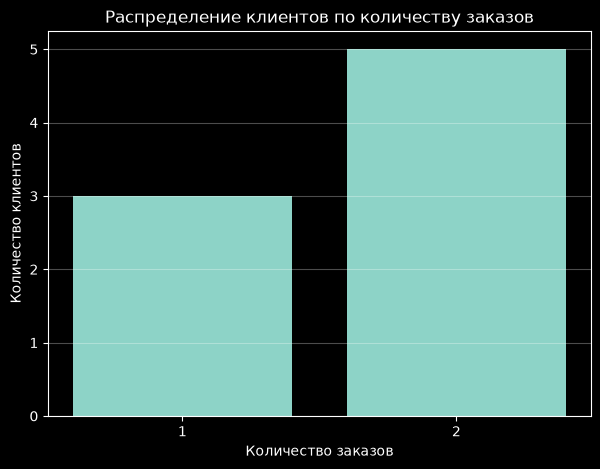

In [72]:
plt.figure(figsize=(7, 5))

plt.bar(
    orders_distribution["orders_count"].astype(str),
    orders_distribution["customers_count"]
)

plt.title("Распределение клиентов по количеству заказов")
plt.xlabel("Количество заказов")
plt.ylabel("Количество клиентов")

plt.grid(axis="y", alpha=0.3)

plt.show()

10. Средний чек и количество заказов.

Рассчитаем среднюю стоимость завершённого заказа и общее количество завершённых заказов.

In [73]:
completed_orders = df_orders[
    df_orders["status"] == "completed"
]

average_check = (
    completed_revenue
    .groupby("order_id")["revenue"]
    .sum()
    .mean()
)

orders_count = completed_orders["order_id"].nunique()

print(f"Количество завершённых заказов: {orders_count}")
print(f"Средний чек: {average_check:,.2f} ₽")

Количество завершённых заказов: 13
Средний чек: 63,115.38 ₽


Вывод.

В магазине было совершено **13 завершённых заказов**.

Средний чек составил **63 115,38 ₽**. Это означает, что в среднем один завершённый заказ приносил магазину около 63 тыс. ₽ выручки.

При этом средний чек заметно зависит от структуры покупок: в некоторых заказах покупались дорогие товары, например смартфоны и ноутбук, поэтому показатель нельзя интерпретировать как типичную стоимость каждой отдельной покупки.

11. Выручка по городам.

Проанализируем распределение выручки между городами клиентов и определим города с наибольшим вкладом в продажи.

In [74]:
city_revenue = (
    completed_revenue
    .merge(
        df_customers[["customer_id", "city"]],
        on="customer_id"
    )
    .groupby("city")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

city_revenue

,city,revenue
0,Москва,297000.0
1,Самара,160000.0
2,Казань,123000.0
3,Санкт-Петербург,91000.0
4,Сочи,85000.0
5,Екатеринбург,60000.0
6,Пермь,4500.0


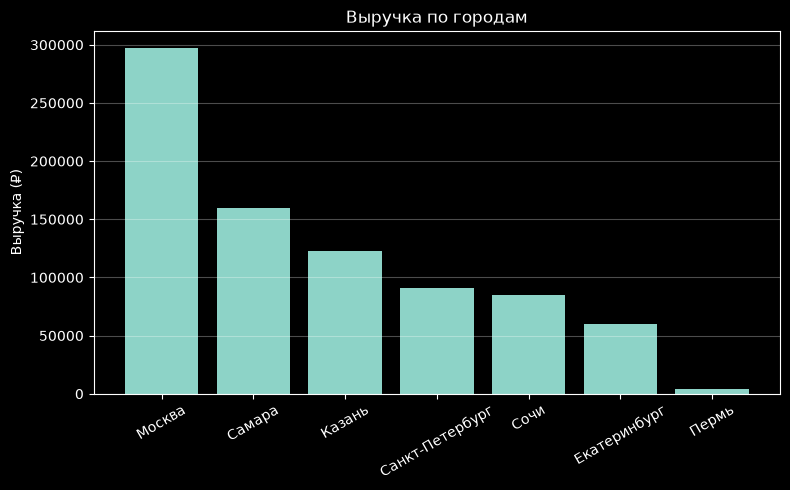

In [75]:
plt.figure(figsize=(8, 5))

plt.bar(
    city_revenue["city"],
    city_revenue["revenue"]
)

plt.title("Выручка по городам")
plt.ylabel("Выручка (₽)")

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Вывод.

Наибольшую выручку магазин получил от клиентов из Москвы — 297 000 ₽.

На втором месте находится Самара — 160 000 ₽, далее идут Казань — 123 000 ₽ и Санкт-Петербург — 91 000 ₽.

Москва является главным городом по объёму выручки и приносит значительно больше остальных регионов. При этом выборка небольшая, поэтому делать вывод о реальном превосходстве города без дополнительных данных пока нельзя.

12. Самые продаваемые товары.

Проанализируем количество проданных единиц каждого товара и определим товары с наибольшим объёмом продаж.

In [76]:
product_quantity = (
    completed_revenue
    .groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

product_quantity

,product_name,quantity
0,Книга по Python,5
1,Стол компьютерный,4
2,Клавиатура Logitech,4
3,Кофеварка Bosch,3
4,iPhone 15,3
5,Наушники Sony,3
6,Samsung Galaxy S24,2
7,Ноутбук Lenovo,2
8,Кресло офисное,1


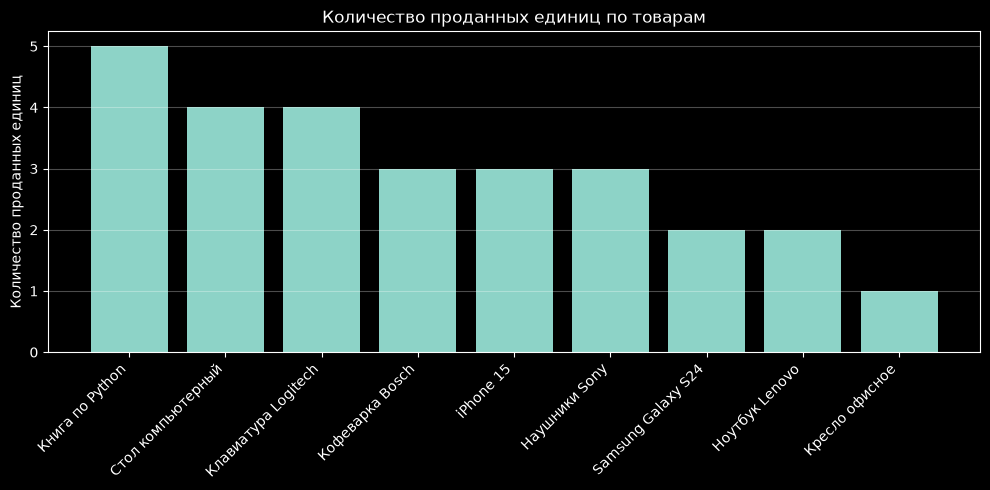

In [77]:
plt.figure(figsize=(10, 5))

plt.bar(
    product_quantity["product_name"],
    product_quantity["quantity"]
)

plt.title("Количество проданных единиц по товарам")
plt.ylabel("Количество проданных единиц")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Вывод.

Наибольшее количество проданых единиц - это "Книги по Python", 5 шт.

Продано по 4 единицы товара "компьютерный стол" и "клавиатура Logitech".

При этом товары-лидеры по количеству продаж не обязательно являются лидерами по выручке. Например, "Книга по Python" продалась чаще всех, но принесла магазину только 7 500 ₽, тогда как "iPhone 15" был продан 3 раза и принёс 270 000 ₽.

Важно одновременного анализировать количество продаж и выручку при оценке эффективности продаж товаров.

13. Среднее количество товаров в заказе.

Определим среднее количество единиц товара, приобретаемых клиентами в одном завершённом заказе.

In [78]:
average_items_per_order = (
    completed_revenue
    .groupby("order_id")["quantity"]
    .sum()
    .mean()
)

print(
    f"Среднее количество товаров в заказе: "
    f"{average_items_per_order:.2f} шт."
)

Среднее количество товаров в заказе: 2.08 шт.


Вывод.

В среднем на один завершённый заказ приходится **2,08 товара**.

Это означает, что покупатели обычно приобретают несколько товаров в рамках одного заказа, а не ограничиваются одной позицией.

14. Динамика количества заказов и выручки.

Сравним количество завершённых заказов и выручку по месяцам, чтобы определить факторы изменения продаж.

In [79]:
monthly_orders = (
    completed_revenue
    .groupby("month")["order_id"]
    .nunique()
    .reset_index(name="orders_count")
)

monthly_orders

,month,orders_count
0,2024-01,2
1,2024-02,1
2,2024-03,2
3,2024-04,1
4,2024-05,2
5,2024-06,2
6,2024-07,2
7,2024-08,1


In [80]:
monthly_analysis = monthly_revenue.merge(
    monthly_orders,
    on="month"
)

monthly_analysis

,month,revenue,orders_count
0,2024-01,197000.0,2
1,2024-02,83000.0,1
2,2024-03,137000.0,2
3,2024-04,70000.0,1
4,2024-05,89500.0,2
5,2024-06,120000.0,2
6,2024-07,110000.0,2
7,2024-08,14000.0,1


In [81]:
monthly_analysis["average_check"] = (
    monthly_analysis["revenue"]
    / monthly_analysis["orders_count"]
)

monthly_analysis

,month,revenue,orders_count,average_check
0,2024-01,197000.0,2,98500.0
1,2024-02,83000.0,1,83000.0
2,2024-03,137000.0,2,68500.0
3,2024-04,70000.0,1,70000.0
4,2024-05,89500.0,2,44750.0
5,2024-06,120000.0,2,60000.0
6,2024-07,110000.0,2,55000.0
7,2024-08,14000.0,1,14000.0


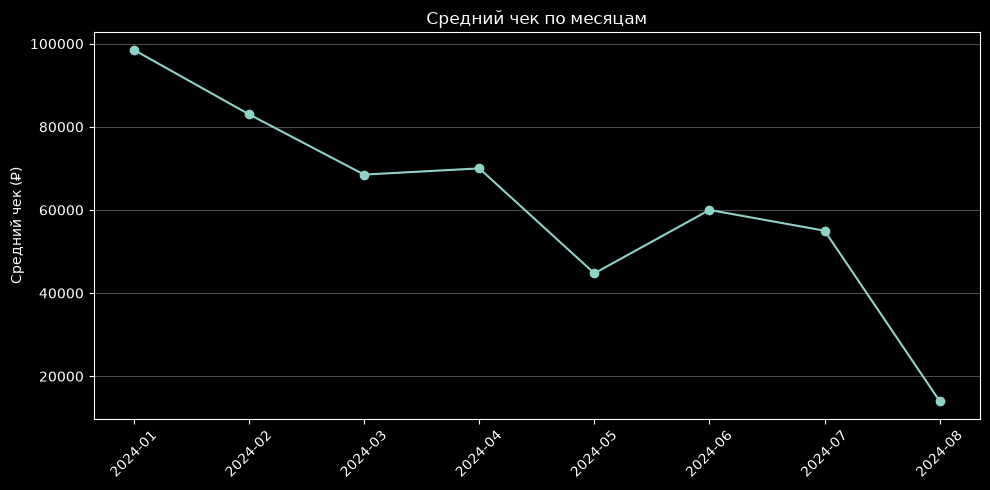

In [82]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_analysis["month"],
    monthly_analysis["average_check"],
    marker="o"
)

plt.title("Средний чек по месяцам")
plt.ylabel("Средний чек (₽)")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Вывод.

Средний чек постепенно снижался в течение рассматриваемого периода.

Максимальное значение наблюдалось в январе — 98 500 ₽, после чего средний чек в целом снижался. В июне произошло небольшое восстановление до 60 000 ₽, однако в августе показатель резко снизился до 14 000 ₽.

Таким образом, снижение выручки в отдельные месяцы связано не только с количеством заказов, но и с уменьшением средней суммы заказа.

Итоговые выводы.

В ходе анализа были получены следующие результаты:

- общая выручка магазина составила **820 500 ₽**;
- средний чек — **63 115 ₽**;
- наибольшую выручку принесла категория **Electronics**;
- лидером продаж стал **iPhone 15**;
- **62,5% клиентов** совершили повторную покупку;
- товары категории **A** по ABC-анализу обеспечили основную часть выручки;
- максимальная выручка наблюдалась в январе, после чего продажи постепенно снижались.

Полученные результаты позволяют определить наиболее прибыльные категории товаров, оценить лояльность клиентов и выявить динамику продаж по месяцам.